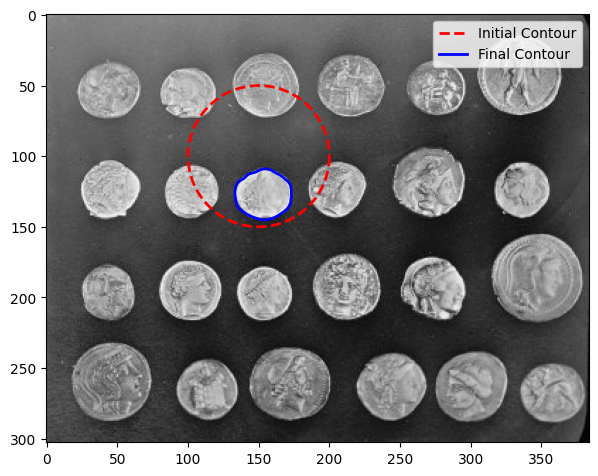

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color
from skimage.filters import gaussian
from skimage.segmentation import active_contour

# Load an inbuilt image from skimage
image = data.coins()

# Convert to grayscale if not already
image_gray = color.rgb2gray(image) if image.ndim == 3 else image

# Create an initial contour (circle around the object)
s = np.linspace(0, 2*np.pi, 100)
r = 100 + 50*np.sin(s)
c = 150 + 50*np.cos(s)
init = np.array([r, c]).T

# Apply active contour model
snake = active_contour(gaussian(image_gray, 3), init, alpha=0.015, beta=10, gamma=0.001)

# Plot results
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(image_gray, cmap=plt.cm.gray)
ax.plot(init[:, 1], init[:, 0], '--r', lw=2, label='Initial Contour')
ax.plot(snake[:, 1], snake[:, 0], '-b', lw=2, label='Final Contour')
ax.legend()
plt.show()
